In [1]:
import svgpathtools
from shapely.geometry import Polygon
from shapely.ops import polygonize
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from xml.etree import ElementTree as ET
import json
import os
import torch
from torchvision import transforms
import cv2
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from scipy.interpolate import RBFInterpolator

# Настройки шаблонов

In [2]:
def load_template_from_svg(svg_path):
    """
    Загружает шаблон из SVG, создает структуру данных
    
    Ожидаемая структура SVG:
    - Слой с суфиксом "_contour" - общий контур легкого
    - Остальные слои - сегменты
    - Группа "key_points" с точками внутри (круги 2x2)
    
    Parameters:
    - svg_path: путь к SVG файлу
    
    Returns:
    - template: словарь с ключами:
        * 'lung_contour': Polygon - контур легкого
        * 'segments': dict - словарь сегментов {Polygon}
        * 'key_points': dict - словарь ключевых точек {(x, y)}
        * 'bounds': (minx, miny, maxx, maxy) - границы шаблона
    """

    # Парсим XML для получения структуры групп
    tree = ET.parse(svg_path)
    root = tree.getroot()

    # Получаем все пути с их иерархией
    paths_data = []

    def extract_paths(element, group_path=None):
        if group_path is None:
            group_path = []

        for child in element:
            if child.tag.endswith('g'):
                group_id = child.get('id', '')
                new_path = group_path + [group_id]
                extract_paths(child, new_path)
            elif child.tag.endswith('path'):
                path_id = child.get('id', '')
                paths_data.append({
                    'id': path_id,
                    'group_path': group_path,
                    'depth': len(group_path)
                })

    extract_paths(root)

    # Загружаем SVG
    paths, attributes = svgpathtools.svg2paths(svg_path)

    # Собираем все полигоны
    all_polygons = {}

    for path, attr in zip(paths, attributes):
        name = attr.get('id', '')

        # Собираем точки
        points = []
        for segment in path:
            if hasattr(segment, 'start'):
                points.append((segment.start.real, segment.start.imag))
            if hasattr(segment, 'end') and segment.end not in points:
                points.append((segment.end.real, segment.end.imag))

        all_polygons[name] = Polygon(points)

    # Находим контур легкого
    lung_contour_name = [name for name in all_polygons.keys() if name.endswith('_contour')][0]
    lung_contour = all_polygons[lung_contour_name]
    print(f"  ✓ Найден контур легкого: '{lung_contour_name}'")

    # Формируем сегменты и ключевые точки
    segments = {}
    key_points = {}

    for name, poly in all_polygons.items():
        if name == lung_contour_name:
            continue

        # Находим данные о путях
        path_info = next((d for d in paths_data if d['id'] == name), None)

        if path_info and path_info['group_path']:
            last_group = path_info['group_path'][-1]

            if last_group == 'key_points':
                # Это ключевая точка — извлекаем её центр
                centroid = poly.centroid
                key_points[name] = (centroid.x, centroid.y)
                print(f"  ✓ Ключевая точка: {name} ({centroid.x:.1f}, {centroid.y:.1f})")
            else:
                # Это сегмент (в другой группе или без группы)
                segments[name] = poly
                print(f"  ✓ Сегмент: {name}")

    print(f"  ✓ Загружено сегментов: {len(segments)}")
    print(f"  ✓ Загружено ключевых точек: {len(key_points)}")

    # Собираем все полигоны для границ
    all_polys = [lung_contour] + list(segments.values())

    bounds = (
        min(min(p.exterior.xy[0]) for p in all_polys),
        min(min(p.exterior.xy[1]) for p in all_polys),
        max(max(p.exterior.xy[0]) for p in all_polys),
        max(max(p.exterior.xy[1]) for p in all_polys),
    )

    template = {
        "lung_contour": lung_contour,
        "segments": segments,
        "key_points": key_points,
        "bounds": bounds,
    }

    print(f"  ✓ Границы: X [{bounds[0]:.0f}, {bounds[2]:.0f}], Y [{bounds[1]:.0f}, {bounds[3]:.0f}]")

    return template

In [3]:
def display_template(template, figsize=(12, 10), show_segment_names=True, 
                    show_key_points=True, lung_color='darkblue', alpha=0.5,
                    key_point_color='red', key_point_size=30):
    """
    Отображает загруженный шаблон

    Parameters:
    - template: словарь от load_template_from_svg
    - figsize: размер рисунка
    - show_segment_names: показывать названия сегментов
    - show_key_points: показывать ключевые точки
    - lung_color: цвет контура легкого
    - alpha: прозрачность заливки сегментов
    - key_point_color: цвет ключевых точек
    - key_point_size: размер ключевых точек
    """
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Рисуем контур легкого
    if template['lung_contour']:
        x, y = template['lung_contour'].exterior.xy
        ax.plot(x, y, 'b-', linewidth=2, color=lung_color, label='Контур легкого')

    # Рисуем сегменты
    segments = template['segments']
    if segments:
        # Генерируем цвета
        colors = plt.cm.tab10(np.linspace(0, 1, len(segments)))

        for (name, geom), color in zip(sorted(segments.items()), colors):
            x, y = geom.exterior.xy
            ax.fill(x, y, alpha=alpha, color=color)
            ax.plot(x, y, 'k-', linewidth=0.8, alpha=0.7)

            if show_segment_names:
                # Подписываем каждую часть
                cx, cy = geom.centroid.x, geom.centroid.y
                ax.plot(cx, cy, 'ro', markersize=4)
                ax.text(cx, cy, name, fontsize=9, fontweight='bold', ha='center', va='center',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9))

    # Рисуем ключевые точки
    if show_key_points and 'key_points' in template and template['key_points']:
        key_points = template['key_points']

        # Рисуем точки
        x_coords = [coord[0] for coord in key_points.values()]
        y_coords = [coord[1] for coord in key_points.values()]
        ax.scatter(x_coords, y_coords, c=key_point_color, s=key_point_size, 
                  zorder=5, label='Ключевые точки', linewidth=1)

        # Подписываем точки
        for name, (x, y) in key_points.items():
            ax.text(x, y - 15, name, fontsize=8, fontweight='bold', ha='center', va='bottom',
                   bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.8))

    # Настройки отображения
    bounds = template['bounds']
    ax.set_xlim(bounds[0] - 200, bounds[2] + 200)
    ax.set_ylim(bounds[3] + 40, bounds[1] - 80)

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlabel('X (пиксели)')
    ax.set_ylabel('Y (пиксели)')

    
    # Статистика в заголовке
    ax.set_title(f'Шаблон: {len(segments)} сегментов, {len(template["key_points"])} ключевых точек', 
                fontsize=12, pad=20)

    plt.tight_layout()
    plt.show()

  ✓ Найден контур легкого: 'right_lung_contour'
  ✓ Сегмент: R8
  ✓ Сегмент: R5
  ✓ Сегмент: R4
  ✓ Сегмент: R3
  ✓ Сегмент: R2
  ✓ Сегмент: R1
  ✓ Ключевая точка: right_diaphragm_dome (549.4, 1987.5)
  ✓ Ключевая точка: right_medial_lower (1007.5, 1690.0)
  ✓ Ключевая точка: right_lateral_lower (68.5, 2090.5)
  ✓ Ключевая точка: right_medial_middle (1068.8, 1386.0)
  ✓ Ключевая точка: right_lateral_middle (4.5, 1386.0)
  ✓ Ключевая точка: right_central_lung (483.5, 1046.0)
  ✓ Ключевая точка: right_medial_hilum_level (1103.0, 883.0)
  ✓ Ключевая точка: right_lateral_hilum_level (108.0, 882.0)
  ✓ Ключевая точка: right_hilum_angle (856.5, 883.0)
  ✓ Ключевая точка: right_medial_upper (1005.7, 442.5)
  ✓ Ключевая точка: right_lateral_upper (314.5, 440.5)
  ✓ Ключевая точка: right_apex (897.5, 1.0)
  ✓ Загружено сегментов: 6
  ✓ Загружено ключевых точек: 12
  ✓ Границы: X [0, 1106], Y [1, 2107]


C:\Users\TTankrat\AppData\Local\Temp\ipykernel_14964\4294747621.py:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax.plot(x, y, 'b-', linewidth=2, color=lung_color, label='Контур легкого')


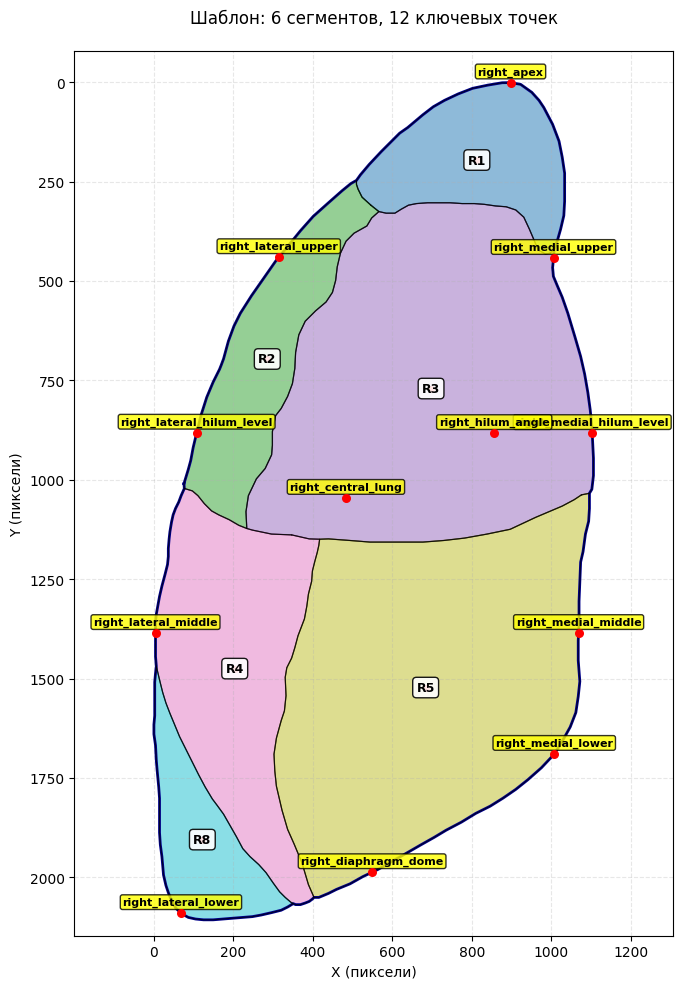

In [4]:
template1 = load_template_from_svg('Right_Lung_PA.svg')
display_template(template1)

  ✓ Найден контур легкого: 'right_lung_lateral_contour'
  ✓ Сегмент: RL10
  ✓ Сегмент: RL9
  ✓ Сегмент: RL8
  ✓ Сегмент: RL6
  ✓ Сегмент: RL5
  ✓ Сегмент: RL4
  ✓ Сегмент: RL3
  ✓ Сегмент: RL2
  ✓ Сегмент: RL1
  ✓ Ключевая точка: right_diaphragm_dome (906.5, 2123.0)
  ✓ Ключевая точка: posterior_lower (180.5, 2074.0)
  ✓ Ключевая точка: anterior_lower (1674.5, 1592.0)
  ✓ Ключевая точка: posterior_middle (6.5, 1335.5)
  ✓ Ключевая точка: anterior_middle (1646.0, 1335.5)
  ✓ Ключевая точка: right_central_lung (803.7, 1062.0)
  ✓ Ключевая точка: posterior_hilum_level (16.0, 838.5)
  ✓ Ключевая точка: anterior_hilum_level (1478.0, 838.5)
  ✓ Ключевая точка: hilum_center (674.5, 838.5)
  ✓ Ключевая точка: posterior_upper (128.0, 419.8)
  ✓ Ключевая точка: anterior_upper (1178.9, 419.8)
  ✓ Ключевая точка: apex (701.0, 1.0)
  ✓ Загружено сегментов: 9
  ✓ Загружено ключевых точек: 12
  ✓ Границы: X [0, 1679], Y [1, 2135]


C:\Users\TTankrat\AppData\Local\Temp\ipykernel_14964\4294747621.py:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax.plot(x, y, 'b-', linewidth=2, color=lung_color, label='Контур легкого')


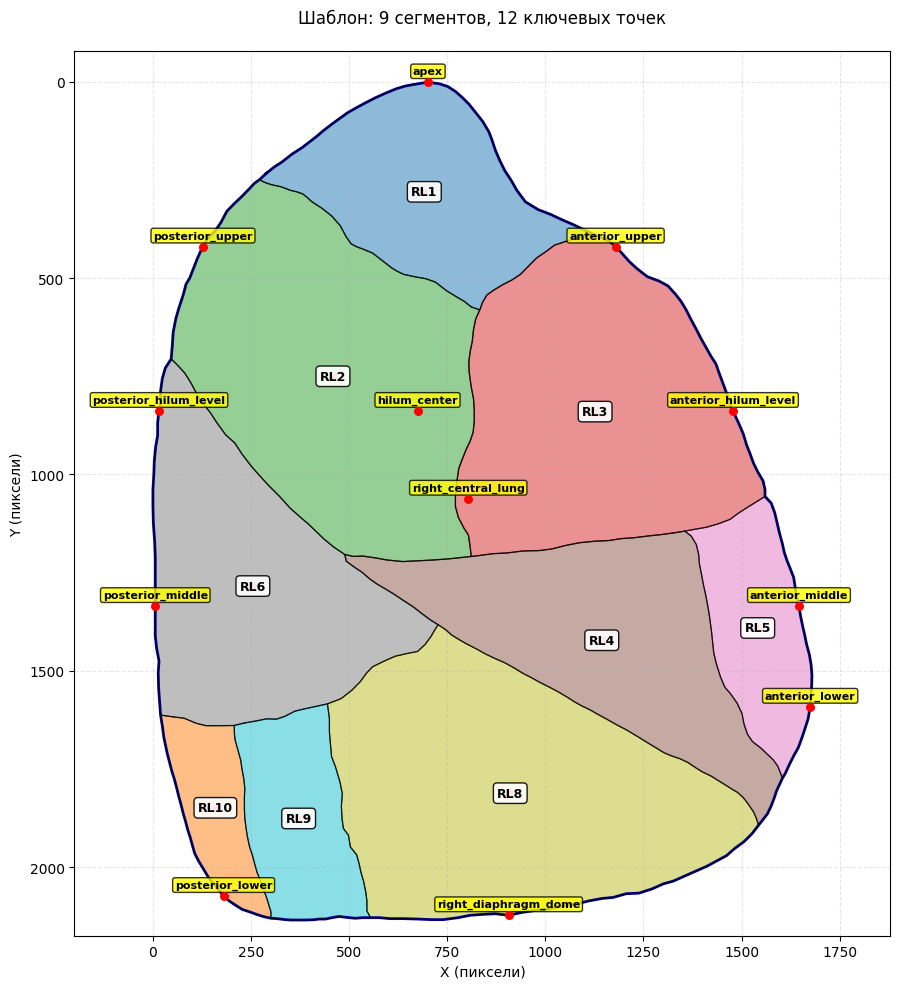

In [5]:
template1 = load_template_from_svg("Right_Lung_Lateral.svg")
display_template(template1)

# Настройка выделения ключевых точек на рентгене

In [6]:
def load_points_from_json(json_path):
    """Загружает точки из mrk.json"""
    with open(json_path, "r") as f:
        data = json.load(f)

    control_points = data["markups"][0]["controlPoints"]

    points = {}
    for cp in control_points:
        name = cp["label"]
        # position = [x, y, z] в LPS координатах
        x, y, _ = cp["position"]
        points[name] = (x, y)

    return points

def convert_to_pixel_coordinates(points_lps, img_path, spacing=(0.139, 0.139)):
    """
    Конвертирует LPS точки в пиксельные координаты
    
    Parameters:
    - points_lps: словарь {имя: (x, y)} в LPS координатах
    - img_path: путь к PNG изображению
    - spacing: (row_spacing, col_spacing) в мм
    """
    img = Image.open(img_path)

    width, height = img.size
    row_spacing, col_spacing = spacing

    print(f"Информация об изображении:")
    print(f"  Размер: {width} x {height} (ширина x высота)")
    print(f"  Spacing: {spacing}")

    points_pixel = {}
    print("\nКлючевые точки пациента:")
    for name, (x_lps, y_lps) in points_lps.items():
        # Конвертация LPS -> пиксели
        col = x_lps / col_spacing
        row = y_lps / row_spacing

        # Проверка границ
        if 0 <= row < height and 0 <= col < width:
            points_pixel[name] = (col, row)
            print(
                f"  {name}: LPS ({x_lps:.1f}, {y_lps:.1f}) → пиксели ({col:.1f}, {row:.1f})"
            )
        else:
            print(f"  {name}: вне изображения! ({col:.1f}, {row:.1f})")

    return points_pixel


def verify_points_on_image(img_path, points_pixel, inverting = False):
    """Проверяет, правильно ли легли точки"""
    img = Image.open(img_path)
    img_array = np.array(img)
    
    # Инверсия для отображения
    if inverting:
        img_array = np.max(img_array) - img_array

    plt.figure(figsize=(15, 12))
    plt.imshow(img_array, cmap="gray")

    for i, (name, (x, y)) in enumerate(points_pixel.items()):
        if i < 5:
            color = "darkred"
        else:
            color = "green"

        plt.plot(x, y, "o", color=color, markersize=8)
        plt.text(
            x,
            y - 30,
            name,
            color=color,
            fontsize=9,
            fontweight="bold",
            ha="center",
            bbox=dict(facecolor="black", alpha=0.5),
        )

    plt.title("Проверка конвертации LPS → пиксели")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

Информация об изображении:
  Размер: 2302 x 2960 (ширина x высота)
  Spacing: (0.139, 0.139)

Ключевые точки пациента:
  right_apex: LPS (113.9, 16.9) → пиксели (819.7, 121.7)
  right_hilum_angle: LPS (116.3, 143.2) → пиксели (836.8, 1030.0)
  right_lateral_lower: LPS (24.3, 319.6) → пиксели (175.1, 2299.0)
  right_medial_lower: LPS (120.5, 245.7) → пиксели (867.1, 1767.9)
  right_diaphragm_dome: LPS (70.4, 261.1) → пиксели (506.3, 1878.1)
  left_apex: LPS (207.0, 18.9) → пиксели (1489.4, 135.9)
  left_hilum_angle: LPS (212.1, 158.5) → пиксели (1526.0, 1140.1)
  left_lateral_lower: LPS (278.9, 322.5) → пиксели (2006.2, 2319.9)
  left_medial_lower: LPS (216.5, 257.5) → пиксели (1557.6, 1852.3)
  left_diaphragm_dome: LPS (248.2, 276.8) → пиксели (1785.5, 1991.5)


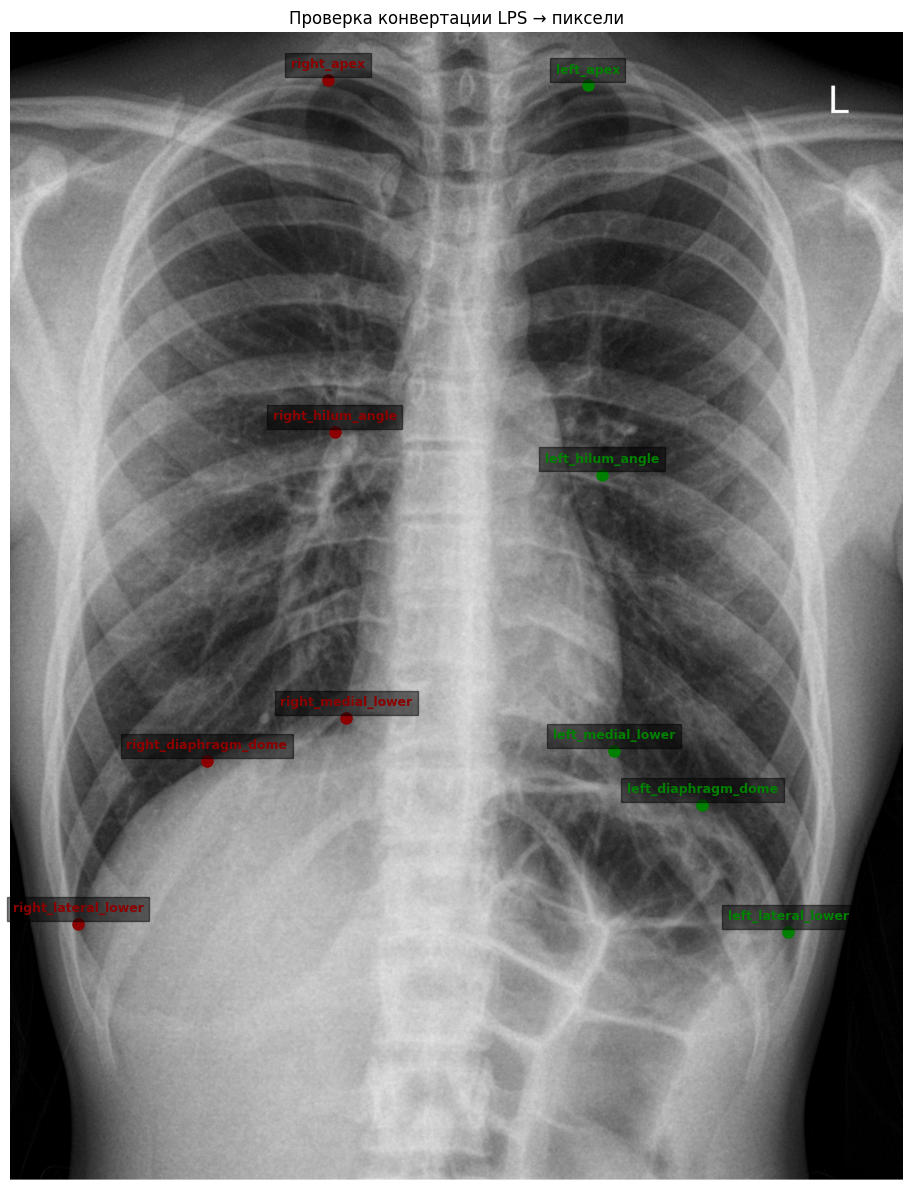

In [7]:
# Использование
points_lps = load_points_from_json(
    "./part1/data/X-chest-dataset/x-chest/key_points_PA_fullsize/key_points_17123_PA.mrk.json"
)
points_pixel = convert_to_pixel_coordinates(
    points_lps, "./part1/data/X-chest-dataset/x-chest/img_PA_fullsize/img_17123.png"
)
verify_points_on_image(
    "./part1/data/X-chest-dataset/x-chest/img_PA_fullsize/img_17123.png", points_pixel
)

## Определение геометрических ключевых точек

### Уменьшаем ИМВР и масок до размера 512x512 с сохранением (из 1 части, универсальная)

In [9]:
class ChestXrayDataset(Dataset):
    def __init__(self, img_dir, mask_dir, target_size=(256, 256), 
                 transform_img=None, transform_mask=None, augmentations=None, 
                 save_resized=False, invert_image=False, 
                 output_dir=None, color2label=None, 
                 img_subdir='img', mask_subdir='masks'):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.target_size = target_size
        self.transform_img = transform_img
        self.transform_mask = transform_mask
        self.augmentations = augmentations
        self.save_resized = save_resized
        self.output_dir = output_dir
        self.invert_image = invert_image
        self.img_subdir = img_subdir
        self.mask_subdir = mask_subdir
        self.restoration_info = {}

        self.img_names = sorted(os.listdir(img_dir))
        self.mask_names = sorted(os.listdir(mask_dir))
        
        # Сопоставление оттенков к классам
        if color2label is None:
            self.color2label = {
                0: 0,      # фон - черный
                85: 1,     # средостение - темно-серый
                170: 2,    # тело - светло-серый
                255: 3     # легкие - белый
            }
        else:
            self.color2label = color2label

        # Создание дирректорий
        if self.save_resized and self.output_dir:
            os.makedirs(os.path.join(self.output_dir, f'{img_subdir}_{target_size[0]}'), exist_ok=True)
            os.makedirs(os.path.join(self.output_dir, f'{mask_subdir}_{target_size[0]}'), exist_ok=True)

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_names[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_names[idx])

        image = Image.open(img_path)
        mask = Image.open(mask_path).convert("L")

        # Сохраняем оригинальный размер
        original_size = image.size

        # Если это 16-битное изображение
        if image.mode in ['I;16', 'I;16B', 'I;16L']:
            img_array = np.array(image)
            # Нормализуем 16-бит в 8-бит для отображения
            if img_array.max() > 0:
                img_array = (img_array / img_array.max() * 255).astype(np.uint8)
            image = Image.fromarray(img_array, mode='L')
        
        if image.mode != 'L':
            image = image.convert('L')

        if self.invert_image:
            image = Image.fromarray(255 - np.array(image))
        
        # Аугментации до преобразования маски в классы
        if self.augmentations:
            image, mask = self.augmentations(image, mask)

        # Преобразование маски в индекс классов
        mask = np.array(mask)
        mask_class = np.zeros_like(mask, dtype=np.uint8)
        for color_val, label_val in self.color2label.items():
            mask_class[mask == color_val] = label_val

        # Конвертируем маску обратно в PIL для трансформаций resize
        mask_class = Image.fromarray(mask_class)
        
        # Ресайз с паддингом
        image_padded, img_bbox = self.resize_with_padding(image,"img", self.target_size, 0)
        mask_padded, mask_bbox = self.resize_with_padding(mask_class, "mask", self.target_size, 0)

        # Сохраняем информацию для восстановления
        self.restoration_info[idx] = {
            'original_size': original_size,
            'img_bbox': img_bbox,
            'mask_bbox': mask_bbox,
            'img_name': self.img_names[idx]
        }
        
        # Сохранение уменьшенных версий
        if self.save_resized and self.output_dir:
            self.save_resized_versions(idx, image_padded, mask_padded)
        
        # Примение стандартных трансформаций
        if self.transform_img:
            image = self.transform_img(image_padded)
        else:
            image = transforms.ToTensor()(image_padded)
        
        if self.transform_mask:
            mask_class = self.transform_mask(mask_padded)
            if isinstance(mask_class, Image.Image):
                mask_class = torch.from_numpy(np.array(mask_class)).long()
        else:
            mask_class = torch.from_numpy(np.array(mask_padded)).long()

        return image, mask_class
    
    # Ресайз изображения с сохранением пропорций и добавлением паддинга
    def resize_with_padding(self, img, mode, target_size=(256, 256), pad_color=0):
        original_width, original_height = img.size
        target_width, target_height = target_size
        
        # Вычисляем соотношение сторон
        width_ratio = target_width / original_width
        height_ratio = target_height / original_height
        ratio = min(width_ratio, height_ratio)
        
        new_width = int(original_width * ratio)
        new_height = int(original_height * ratio)
        
        if mode == "img":
            img_resized = img.resize((new_width, new_height), Image.BILINEAR)
        elif mode == "mask":
            img_resized = img.resize((new_width, new_height), Image.NEAREST)
        new_img = Image.new(img.mode, (target_width, target_height), pad_color)
        
        paste_x = (target_width - new_width) // 2
        paste_y = (target_height - new_height) // 2
        new_img.paste(img_resized, (paste_x, paste_y))
        
        return new_img, (paste_x, paste_y, new_width, new_height)

    # Сохранение уменьшенных изображений и маскок
    def save_resized_versions(self, idx, img_padded, mask_padded):
        img_np = np.array(img_padded)
        if img_np.dtype != np.uint8:
            img_min, img_max = img_np.min(), img_np.max()
            if img_max > img_min:
                img_np = ((img_np - img_min) / (img_max - img_min) * 255).astype(np.uint8)
        
        # Конвертируем обратно в numpy для сохранения
        mask_np = np.array(mask_padded)
        mask_visible = np.zeros_like(mask_np, dtype=np.uint8)

        # Обратное преобразование из label в цвет
        label2color = {v: k for k, v in self.color2label.items()}
        for label_val, color_val in label2color.items():
            mask_visible[mask_np == label_val] = color_val
        
        # Сохраняем
        img_name = self.img_names[idx]
        mask_name = self.mask_names[idx]

        img_path = os.path.join(self.output_dir, f'{self.img_subdir}_{self.target_size[0]}', img_name)
        mask_path = os.path.join(self.output_dir, f'{self.mask_subdir}_{self.target_size[0]}', mask_name)
        
        cv2.imwrite(os.path.join(self.output_dir, f'{self.img_subdir}_{self.target_size[0]}', img_name), img_np)
        cv2.imwrite(os.path.join(self.output_dir, f'{self.mask_subdir}_{self.target_size[0]}', mask_name), mask_visible)

        print(f"Сохранено: {os.path.exists(img_path)}, {os.path.exists(mask_path)}")

    # Получить информацию для восстановления маски до исходного размера
    def get_restoration_info(self, idx):
        return self.restoration_info.get(idx)
    
    # Восстановить маску до исходного размера
    @staticmethod
    def restore_mask_to_original(mask, restoration_info):
        """
        Args:
            mask: уменьшенная маска
            restoration_info: информация из get_restoration_info()
        
        Returns:
            restored_mask: маска в оригинальном размере
        """
        if isinstance(mask, torch.Tensor):
            mask = mask.cpu().numpy()
        
        original_size = restoration_info['original_size']
        paste_x, paste_y, new_width, new_height = restoration_info['mask_bbox']
        
        # Вырезаем область без паддинга
        mask_no_padding = mask[paste_y:paste_y+new_height, paste_x:paste_x+new_width]
        
        # Ресайз до оригинального размера
        mask_original = cv2.resize(mask_no_padding.astype(np.uint8), 
                              (original_size[0], original_size[1]),  # OpenCV: (width, height)
                              interpolation=cv2.INTER_NEAREST)
        
        return mask_original

In [9]:
# Сохранение изображений и масок разрешения 512x512
img_fullsize_PA_root = "./part1/data/X-chest-dataset/x-chest/img_PA_fullsize"
mask_fullsize_PA_root = "./part1/data/X-chest-dataset/x-chest/masks_PA_fullsize"
img_fullsize_L_root = "./part1/data/X-chest-dataset/x-chest/img_L_fullsize"
mask_fullsize_L_root = "./part1/data/X-chest-dataset/x-chest/masks_L_fullsize"

color_scheme = {
    0: 0,    # фон
    255: 1   # легкие
}

resize_save_PA_512_dataset = ChestXrayDataset(
    img_dir=img_fullsize_PA_root,
    target_size = (512,512),
    mask_dir=mask_fullsize_PA_root,
    transform_img=None,
    transform_mask=None,
    save_resized=True,
    invert_image=True,
    output_dir="./part1/data/X-chest-dataset/x-chest",
    color2label = color_scheme,
    img_subdir = 'img_PA',
    mask_subdir = 'masks_PA'
)

resize_save_L_512_dataset = ChestXrayDataset(
    img_dir=img_fullsize_L_root,
    target_size = (512,512),
    mask_dir=mask_fullsize_L_root,
    transform_img=None,
    transform_mask=None,
    save_resized=True,
    invert_image=True,
    output_dir="./part1/data/X-chest-dataset/x-chest",
    color2label = color_scheme,
    img_subdir = 'img_L',
    mask_subdir = 'masks_L'
)

# Сохранение
# PA
for i in range(len(resize_save_PA_512_dataset)):
    img, mask = resize_save_PA_512_dataset[i]
    print(f"Обработан {i+1}/{len(resize_save_PA_512_dataset)}: {resize_save_PA_512_dataset.img_names[i]}")
# L
for i in range(len(resize_save_L_512_dataset)):
    img, mask = resize_save_L_512_dataset[i]
    print(f"Обработан {i+1}/{len(resize_save_L_512_dataset)}: {resize_save_L_512_dataset.img_names[i]}")

C:\Users\TTankrat\AppData\Local\Temp\ipykernel_3924\1614223144.py:59: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(img_array, mode='L')


Сохранено: True, True
Обработан 1/31: img_17123.png
Сохранено: True, True
Обработан 2/31: img_17124.png
Сохранено: True, True
Обработан 3/31: img_17125.png
Сохранено: True, True
Обработан 4/31: img_17126.png
Сохранено: True, True
Обработан 5/31: img_17127.png
Сохранено: True, True
Обработан 6/31: img_17128.png
Сохранено: True, True
Обработан 7/31: img_17141.png
Сохранено: True, True
Обработан 8/31: img_17142.png
Сохранено: True, True
Обработан 9/31: img_17143.png
Сохранено: True, True
Обработан 10/31: img_17144.png
Сохранено: True, True
Обработан 11/31: img_17145.png
Сохранено: True, True
Обработан 12/31: img_17156.png
Сохранено: True, True
Обработан 13/31: img_17157.png
Сохранено: True, True
Обработан 14/31: img_17158.png
Сохранено: True, True
Обработан 15/31: img_17159.png
Сохранено: True, True
Обработан 16/31: img_17180.png
Сохранено: True, True
Обработан 17/31: img_17181.png
Сохранено: True, True
Обработан 18/31: img_17182.png
Сохранено: True, True
Обработан 19/31: img_17183.png
Со

### Алгоритмы определения геометрических ключевых точек

In [ ]:
# Для PA-вида:
#   lateral_upper, medial_upper - середина линии между apex и hilum_angle
#   lateral_hilum_level, medial_hilum_level - на уровне hilum_angle
#   central_lung (ВОЗМОЖНО ПОМЕНЯЕТСЯ!) - середина линии между lateral_lower и apex [середина линии между diaphragm_dome и apex]
#   lateral_middle, medial_middle (ВОЗМОЖНО ПОМЕНЯЕТСЯ!) - середина линии между (середина линии между lateral_hilum_level и medial_hilum_level) и (середина линии между lateral_lower и medial_lower) [середина линии между hilum_angle и diaphragm_dome]

# Для L-вида:
#   anterior_upper, posterior_upper - середина линии между apex и hilum_center
#   anterior_hilum_level, posterior_hilum_level - на уровне hilum_center
#   central_lung - середина линии между diaphragm_dome и apex
#   anterior_middle, posterior_middle - середина линии между (середина линии между anterior_hilum_level и posterior_hilum_level) и (середина линии между anterior_lower и posterior_lower)

# ВОЗМОЖНО для повышения точности контуров придется ввести 2 дополнительные точки для диафрагмы и/или верха!

In [8]:
def get_lung_contours(mask, mod):
    """
    Извлекает контуры легких из бинарной маски

    Parameters:
    - mask: бинарная маска легких (numpy array)
    - mod: режим проекции ('PA', 'LR', 'LL')

    Returns:
    - contours: словарь с контурами легких
    """

    # Конвертация маски
    if isinstance(mask, torch.Tensor):
        mask_np = mask.cpu().numpy().astype(np.uint8)
    elif isinstance(mask, Image.Image):
        mask_np = np.array(mask).astype(np.uint8)
    else:
        mask_np = mask.astype(np.uint8)

    lungs_mask = (mask_np == 255).astype(np.uint8) * 255

    # Контур легких
    contours, _ = cv2.findContours(lungs_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        print("Не найдены контуры легких")
        return None
    # Сортируем контуры по площади (убывание)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    if mod == 'PA':
        if len(contours) >= 2:
            # Берем два самых больших контура
            main_contours = contours[:2]

            # Центроиды для каждого контура
            centroids = []
            for contour in main_contours:
                M = cv2.moments(contour)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    centroids.append((cx, contour))
                else:
                    centroids.append((0, contour))

            # Сортируем по X-координате центроида (возрастание)
            centroids.sort(key=lambda x: x[0])
            left_contour = centroids[0][1]
            right_contour = centroids[1][1]

            return {
                "left_lung": right_contour,
                "right_lung": left_contour,
                "lungs": main_contours,
            }
        else:
            print("Найден только один контур")

    elif mod == "LR" or mod == "LL":
        return {
                'left_lung': None,
                'right_lung': None,
                'lungs': contours[0]
            }


def get_point_on_contour_at_y(contour, y_level):
    """
    Находит точки на контуре на заданном уровне Y

    Parameters:
    - contour: контур в формате OpenCV
    - y_level: целевой уровень Y

    Returns:
    - left_point: точка с минимальным X (левая граница)
    - right_point: точка с максимальным X (правая граница)
    """
    if contour is None or len(contour) == 0:
        print("  Контур None или пуст")
        return None, None

    # Находим все точки контура на заданном уровне Y
    y_int = round(y_level)

    points_at_y = []
    for point in contour:
        x, y = point[0]
        if y == y_int:
            points_at_y.append((x, y))

    if not points_at_y:
        # Выведем все уникальные Y в контуре для отладки
        unique_ys = sorted(set(p[0][1] for p in contour))
        print(
            f"  Не найдены точки на уровне {y_int}\nДоступные Y в контуре: {unique_ys}"
        )
        return None, None

    # Находим крайние точки
    points_at_y.sort(key=lambda p: p[0])  # сортируем по X
    left_point = points_at_y[0]
    right_point = points_at_y[-1]

    return left_point, right_point

def calculate_midpoint(p1, p2, round_mod = False):
    """Возвращает середину отрезка между двумя точками"""
    if round_mod:
        x = round((p1[0] + p2[0]) / 2)
        y = round((p1[1] + p2[1]) / 2)
    else:
        x = (p1[0] + p2[0]) / 2
        y = (p1[1] + p2[1]) / 2
    return (x, y)

def get_geom_key_points(key_points, mask, mod):
    """
    Расчет координат геометрических ключевых точек по анатомическим точкам и маскам

    Parameters:
    - key_points: словарь с анатомическими ключевыми точками в пиксельных координатах
    - mask: маска легких (бинарная) в виде numpy array
    - mod: режим для выбора вида проекции ('PA', 'LR', 'LL')

    Returns:
    - geom_points: словарь с геометрическими ключевыми точками
    """
    # Получаем контуры легких в зависимости от проекции
    contours = get_lung_contours(mask, mod=mod)

    geom_points = {}
    if mod == "PA":
        # Правое легкое
        right_apex = key_points["right_apex"]
        right_hilum_angle = key_points["right_hilum_angle"]
        right_lateral_lower = key_points["right_lateral_lower"]
        right_medial_lower = key_points["right_medial_lower"]

        right_contour = contours.get("right_lung")

        # lateral_upper, medial_upper — на уровне середины между apex и hilum_angle
        y_upper = calculate_midpoint(right_apex, right_hilum_angle)[1]
        left_point, right_point = get_point_on_contour_at_y(
            right_contour, y_upper
        )
        geom_points["right_lateral_upper"] = left_point
        geom_points["right_medial_upper"] = right_point

        # lateral_hilum_level, medial_hilum_level — на уровне hilum_angle
        y_hilum = right_hilum_angle[1]
        left_point, right_point = get_point_on_contour_at_y(
            right_contour, y_hilum
        )
        geom_points["right_lateral_hilum_level"] = left_point
        geom_points["right_medial_hilum_level"] = right_point

        # lateral_middle, medial_middle — на середине между hilum и нижней средней точкой
        lower_mid = calculate_midpoint(right_lateral_lower, right_medial_lower)
        y_middle = calculate_midpoint(right_hilum_angle, lower_mid)[1]
        left_point, right_point = get_point_on_contour_at_y(
            right_contour, y_middle
        )
        geom_points["right_lateral_middle"] = left_point
        geom_points["right_medial_middle"] = right_point

        # central_lung — середина между apex и lateral_lower
        geom_points["right_central_lung"] = calculate_midpoint(
            right_apex, right_lateral_lower, round_mod=True
            )

        # Левое легкое
        left_apex = key_points["left_apex"]
        left_hilum_angle = key_points["left_hilum_angle"]
        left_lateral_lower = key_points["left_lateral_lower"]
        left_medial_lower = key_points["left_medial_lower"]

        left_contour = contours.get("left_lung")

        # lateral_upper, medial_upper — на уровне середины между apex и hilum_angle
        y_upper = calculate_midpoint(left_apex, left_hilum_angle)[1]
        left_point, right_point = get_point_on_contour_at_y(
            left_contour, y_upper
        )
        geom_points["left_lateral_upper"] = right_point
        geom_points["left_medial_upper"] = left_point

        # lateral_hilum_level, medial_hilum_level — на уровне hilum_angle
        y_hilum = left_hilum_angle[1]
        left_point, right_point = get_point_on_contour_at_y(
            left_contour, y_hilum
        )
        geom_points["left_lateral_hilum_level"] = right_point
        geom_points["left_medial_hilum_level"] = left_point

        # lateral_middle, medial_middle — на середине между hilum и нижней средней точкой
        lower_mid = calculate_midpoint(left_lateral_lower, left_medial_lower)
        y_middle = calculate_midpoint(left_hilum_angle, lower_mid)[1]
        left_point, right_point = get_point_on_contour_at_y(
            left_contour, y_middle
        )
        geom_points["left_lateral_middle"] = right_point
        geom_points["left_medial_middle"] = left_point

        # central_lung — середина между apex и lateral_lower
        geom_points["left_central_lung"] = calculate_midpoint(
            left_apex, left_lateral_lower, round_mod=True
            )

    else:
        # Боковая проекция
        apex = key_points["apex"]
        hilum_center = key_points["hilum_center"]
        anterior_lower = key_points["anterior_lower"]
        posterior_lower = key_points["posterior_lower"]
        if mod == 'LR':
            diaphragm_dome = key_points.get("right_diaphragm_dome")
        else:
            diaphragm_dome = key_points.get("left_diaphragm_dome")

        lung_contour = contours["lungs"]

        # anterior_upper, posterior_upper — на уровне середины между apex и hilum_center
        y_upper = calculate_midpoint(apex, hilum_center)[1]
        left_point, right_point = get_point_on_contour_at_y(lung_contour, y_upper)
        geom_points['anterior_upper'] = left_point
        geom_points['posterior_upper'] = right_point

        # anterior_hilum_level, posterior_hilum_level — на уровне hilum_center
        y_hilum = hilum_center[1]
        left_point, right_point = get_point_on_contour_at_y(lung_contour, y_hilum)
        geom_points['anterior_hilum_level'] = left_point
        geom_points['posterior_hilum_level'] = right_point

        # anterior_middle, posterior_middle — на середине между hilum и нижней средней точкой
        lower_mid = calculate_midpoint(anterior_lower, posterior_lower)
        y_middle = calculate_midpoint(hilum_center, lower_mid)[1]
        left_point, right_point = get_point_on_contour_at_y(lung_contour, y_middle)
        geom_points['anterior_middle'] = left_point
        geom_points['posterior_middle'] = right_point

        # central_lung — середина между apex и diaphragm_dome
        geom_points["left_central_lung"] = calculate_midpoint(
            apex, diaphragm_dome, round_mod=True
        )
        geom_points["right_central_lung"] = calculate_midpoint(
            apex, diaphragm_dome, round_mod=True
        )

    return geom_points

Информация об изображении:
  Размер: 2302 x 2960 (ширина x высота)
  Spacing: (0.139, 0.139)

Ключевые точки пациента:
  right_apex: LPS (113.9, 16.9) → пиксели (819.7, 121.7)
  right_hilum_angle: LPS (116.3, 143.2) → пиксели (836.8, 1030.0)
  right_lateral_lower: LPS (24.3, 319.6) → пиксели (175.1, 2299.0)
  right_medial_lower: LPS (120.5, 245.7) → пиксели (867.1, 1767.9)
  right_diaphragm_dome: LPS (70.4, 261.1) → пиксели (506.3, 1878.1)
  left_apex: LPS (207.0, 18.9) → пиксели (1489.4, 135.9)
  left_hilum_angle: LPS (212.1, 158.5) → пиксели (1526.0, 1140.1)
  left_lateral_lower: LPS (278.9, 322.5) → пиксели (2006.2, 2319.9)
  left_medial_lower: LPS (216.5, 257.5) → пиксели (1557.6, 1852.3)
  left_diaphragm_dome: LPS (248.2, 276.8) → пиксели (1785.5, 1991.5)

Геометрические точки:
  right_lateral_upper: (312.0, 576.0)
  right_medial_upper: (1025.0, 576.0)
  right_lateral_hilum_level: (220.0, 1030.0)
  right_medial_hilum_level: (997.0, 1030.0)
  right_lateral_middle: (171.0, 1532.0)
 

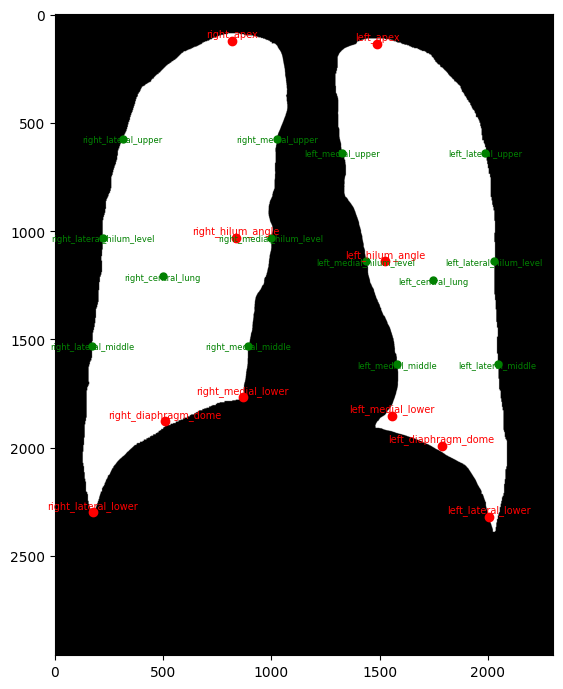

In [9]:
# 1. Загружаем точки
points_lps = load_points_from_json(
    "./part1/data/X-chest-dataset/x-chest/key_points_PA_fullsize/key_points_17123_PA.mrk.json"
)

# 2. Загружаем маску
mask_img = Image.open(
    "./part1/data/X-chest-dataset/x-chest/masks_PA_fullsize/seg_17123.png"
)
mask = np.array(mask_img)

# 3. Конвертируем в пиксельные координаты
points_pixel = convert_to_pixel_coordinates(
    points_lps,
    "./part1/data/X-chest-dataset/x-chest/masks_PA_fullsize/seg_17123.png",
)

# 4. Рассчитываем геометрические точки
geom_points = get_geom_key_points(points_pixel, mask, mod="PA")

print("\nГеометрические точки:")
for name, coords in geom_points.items():
    if coords is not None:
        print(f"  {name}: ({coords[0]:.1f}, {coords[1]:.1f})")
    else:
        print(f"  {name}: None")

# 5. Визуализируем маску и точки
plt.figure(figsize=(15, 7))

# Показываем маску
mask_left = (mask == 255).astype(np.uint8) * 255
plt.imshow(mask_left, cmap="gray")

# Рисуем анатомические точки левого легкого
for name, (x, y) in points_pixel.items():
    if name.startswith("left_"):
        plt.plot(x, y, "ro", markersize=6)
        plt.text(
            x,
            y - 20,
            name,
            fontsize=7,
            ha="center",
            color="red"
        )

# Рисуем геометрические точки левого легкого
for name, coords in geom_points.items():
    if coords is not None and name.startswith("left_"):
        x, y = coords
        plt.plot(x, y, "go", markersize=5)
        plt.text(
            x,
            y + 15,
            name,
            fontsize=6,
            ha="center",
            color="green"
        )

# Рисуем анатомические точки правого легкого
for name, (x, y) in points_pixel.items():
    if name.startswith("right_"):
        plt.plot(x, y, "ro", markersize=6)
        plt.text(
            x,
            y - 20,
            name,
            fontsize=7,
            ha="center",
            color="red"
        )

# Рисуем геометрические точки правого легкого
for name, coords in geom_points.items():
    if coords is not None and name.startswith("right_"):
        x, y = coords
        plt.plot(x, y, "go", markersize=5)
        plt.text(
            x,
            y + 15,
            name,
            fontsize=6,
            ha="center",
            color="green"
        )


plt.tight_layout()
plt.show()

## Алгоритм деформации шаблонов по найденным точкам

In [116]:
def tps_warp(points_template, patient_points, points_to_warp):
    """
    Thin Plate Spline деформация

    Parameters:
    - points_template: координаты ключевых точек в шаблоне
    - patient_points: координаты ключевых точек у пациента
    - points_to_warp: все точки, которые нужно деформировать

    Returns:
    - warped_points: (m, 2) деформированные точки
    """

    # Создаём интерполянты для X и Y
    rbf_x = RBFInterpolator(points_template, patient_points[:, 0:1], kernel="thin_plate_spline")
    rbf_y = RBFInterpolator(points_template, patient_points[:, 1:2], kernel="thin_plate_spline")

    # Применяем ко всем точкам
    warped_x = rbf_x(points_to_warp).flatten()
    warped_y = rbf_y(points_to_warp).flatten()

    return np.column_stack([warped_x, warped_y])


def deform_template(template, patient_anatom_points, mask, mod):
    """
    Деформирует шаблон под пациента

    Parameters:
    - template: словарь от load_template_from_svg (содержит 'lung_contour', 'segments', 'key_points')
    - patient_anatom_points: словарь {имя_точки: (x, y)} в пиксельных координатах
    - mask: маска легких пациента
    - mod: режим проекции ('PA','LR','LL')

    Returns:
    - deformed: словарь с деформированными сегментами и контуром
    """
    # 1. Рассчитываем геометрические точки пациента на основе анатомических
    patient_geom_points = get_geom_key_points(patient_anatom_points, mask, mod)

    # 2. Объединяем анатомические и геометрические точки пациента
    patient_all_points = {**patient_anatom_points, **patient_geom_points}

    # 3. Извлекаем ключевые точки шаблона и сопоставляем с точками пациента
    template_key_points = {}
    patient_key_points_matched = {}

    for name, pt_patient in patient_all_points.items():
        if name in template["key_points"]:
            template_key_points[name] = template["key_points"][name]
            patient_key_points_matched[name] = pt_patient

    # Преобразуем в numpy массивы
    template_pts = np.array(list(template_key_points.values()))
    patient_pts = np.array(list(patient_key_points_matched.values()))

    print(f"Используется {len(template_pts)} ключевых точек для деформации")

    # 4. Собираем все точки для деформации
    all_points = []

    # Контур легкого
    lung_contour_points = np.array(template["lung_contour"].exterior.coords)
    all_points.append(lung_contour_points)

    # Сегменты
    segment_shapes = {}  # информация о структуре
    for name, geom in template["segments"].items():
        points = np.array(geom.exterior.coords)
        all_points.append(points)
        segment_shapes[name] = points

    # Объединяем все точки
    all_points_flat = np.vstack(all_points) if all_points else np.array([])

    if len(all_points_flat) == 0:
        raise ValueError("Нет точек для деформации")

    # 5. Применяем деформацию
    warped_points = tps_warp(template_pts, patient_pts, all_points_flat)

    # 6. Восстанавливаем структуру
    idx = 0
    deformed = {
        "lung_contour": None,
        "segments": {},
        "anatom_key_points": patient_anatom_points,
        "geom_key_points": patient_geom_points,
    }

    # Восстанавливаем контур легкого
    n_lung = len(lung_contour_points)
    deformed_lung_contour = warped_points[idx : idx + n_lung]
    deformed["lung_contour"] = Polygon(deformed_lung_contour)
    idx += n_lung

    # Восстанавливаем сегменты
    for name, original_points in segment_shapes.items():
        n_points = len(original_points)
        warped_seg_points = warped_points[idx : idx + n_points]
        deformed["segments"][name] = Polygon(warped_seg_points)
        idx += n_points

    return deformed

In [117]:
def visualize_deformation(
    results, anatom_points, geom_points, img_path, mod, figsize=(18, 12)
):
    """
    Визуализирует результат деформации

    Parameters:
    - results: словарь с результатами от process_patient_pipeline
    - anatom_points: анатомические ключевые точки в пиксельных координатах
    - geom_points: геометрические ключевые точки 
    - img_path: путь к рентгеновскому изображению (для отображения)
    - mod: режим ('PA', 'LR', 'LL')
    - figsize: размер рисунка
    """

    img = Image.open(img_path)
    img_array = np.array(img)

    if mod == "PA":
        # 1. Шаблон
        fig, axes = plt.subplots(1, 3, figsize=figsize)

        ax0 = axes[0]
        ax0.invert_yaxis()

        template_right = results["right"]["template"]
        template_left = results["left"]["template"]

        shift = img_array.shape[1] * 0.55

        # Контуры
        x, y = template_right["lung_contour"].exterior.xy
        x1, y1 = template_left["lung_contour"].exterior.xy
        ax0.plot(x, y, "b-", linewidth=2, alpha=0.7)
        ax0.plot(np.array(x1) + shift, y1, "b-", linewidth=2, alpha=0.7)
        # Сегменты
        for geom in template_right["segments"].values():
            x, y = geom.exterior.xy
            ax0.fill(x, y, alpha=0.5)
        for geom in template_left["segments"].values():
            x, y = geom.exterior.xy
            ax0.fill(np.array(x) + shift, y, alpha=0.4)
        # Ключевые точки
        for name, (x, y) in template_right["key_points"].items():
            ax0.plot(x, y, "ro", markersize=5)
            ax0.text(x, y - 30, name, fontsize=8, ha="right")
        for name, (x, y) in template_left["key_points"].items():
            ax0.plot(np.array(x) + shift, y, "ro", markersize=5)
            ax0.text(np.array(x) + shift, y + 30, name, fontsize=8, ha="left")
        ax0.set_title("Шаблоны легких")
        ax0.set_aspect("equal")

        # 2. Ключевые точки пациента
        ax1 = axes[1]
        ax1.imshow(img_array, cmap="gray", origin="upper")
        # Анатомические точки
        for name, (x, y) in anatom_points.items():
            ax1.plot(x, y, "go", markersize=5)
            ax1.text(x, y - 30, name, fontsize=8, ha="center", color="green")
        # Геометрические точки
        for name, (x, y) in geom_points.items():
            ax1.plot(x, y, "bo", markersize=4)
            ax1.text(x, y + 30, name, fontsize=7, color="blue")
        ax1.set_title(f"Ключевые точки ({len(anatom_points)} анат. + {len(geom_points)} геом.)")
        ax1.set_aspect("equal")

        # 3. Деформированный шаблон
        ax2 = axes[2]
        ax2.imshow(img_array, cmap="gray", origin="upper")
        # Деформированные контуры
        deformed_right = results["right"]["deformed"]
        deformed_left = results["left"]["deformed"]
        x, y = deformed_right["lung_contour"].exterior.xy
        x1, y1 = deformed_left["lung_contour"].exterior.xy
        ax2.plot(x, y, "b-", linewidth=2, alpha=0.7, label="Деформ. контур")
        ax2.plot(x1, y1, "b-", linewidth=2, alpha=0.7)
        # Анатомические точки
        for name, (x, y) in anatom_points.items():
            ax2.plot(x, y, "go", markersize=4)
        # Геометрические точки
        for name, (x, y) in geom_points.items():
            ax2.plot(x, y, "bo", markersize=4)
        # Сегменты
        for geom in deformed_right["segments"].values():
            x, y = geom.exterior.xy
            ax2.fill(x, y, alpha=0.5)
        for geom in deformed_left["segments"].values():
            x, y = geom.exterior.xy
            ax2.fill(x, y, alpha=0.5)
        # Контур пациента
        x, y = results["right"]["lung_contour"][:, 0], results["right"]["lung_contour"][:, 1]
        ax2.plot(x, y, "r--", linewidth=2, alpha=0.7, label="Контур по маске")
        x1, y1 = results["left"]["lung_contour"][:, 0], results["left"]["lung_contour"][:, 1]
        ax2.plot(x1, y1, "r--", linewidth=2)

        ax2.set_title("Деформированные шаблоны")
        ax2.set_aspect("equal")
        ax2.legend(loc="lower left")

    else:
        # Боковая проекция
        fig, axes = plt.subplots(2, 3, figsize=figsize)

        # Ближнее легкое
        # 1. Шаблон
        ax00 = axes[0, 0]
        ax00.invert_yaxis()
        # Контур
        template_near = results["near"]["template"]
        x, y = template_near["lung_contour"].exterior.xy
        ax00.plot(x, y, "b-", linewidth=2, alpha=0.7)
        # Сегменты
        for geom in template_near["segments"].values():
            x, y = geom.exterior.xy
            ax00.fill(x, y, alpha=0.5)
        # Ключевые точки
        for name, (x, y) in template_near["key_points"].items():
            ax00.plot(x, y, "ro", markersize=5)
            ax00.text(x, y - 30, name, fontsize=8, ha="center")
        ax00.set_title(f"Ближнее легкое (шаблон: {mod})")
        ax00.set_aspect("equal")

        # 2. Ключевые точки
        ax01 = axes[0, 1]
        ax01.imshow(img_array, cmap="gray", origin="upper")
        # Анатомические точки
        for name, (x, y) in anatom_points.items():
            ax01.plot(x, y, "go", markersize=5)
            ax01.text(x, y - 30, name, fontsize=8, ha="center", color="green")
        # Геометрические точки
        for name, (x, y) in geom_points.items():
            ax01.plot(x, y, "bo", markersize=4)
            ax01.text(x, y + 30, name, fontsize=7, color="blue")
        ax01.set_title(f"Ключевые точки ({len(anatom_points)} анат. + {len(geom_points)} геом.)")
        ax01.set_aspect("equal")

        # 3. Деформированный шаблон
        ax02 = axes[0, 2]
        ax02.imshow(img_array, cmap='gray', origin='upper')
        # Деформированный контур
        deformed_near = results['near']['deformed']
        x, y = deformed_near["lung_contour"].exterior.xy
        ax02.plot(x, y, "b-", linewidth=2, alpha=0.7, label="Деформ. контур")
        # Анатомические точки
        for name, (x, y) in anatom_points.items():
            ax02.plot(x, y, "go", markersize=4)
        # Геометрические точки
        for name, (x, y) in geom_points.items():
            ax02.plot(x, y, "bo", markersize=4)
        # Сегменты
        for geom in deformed_near["segments"].values():
            x, y = geom.exterior.xy
            ax02.fill(x, y, alpha=0.5)
        # Контур пациента
        x, y = results['near']['lung_contour'][:, 0], results['near']['lung_contour'][:, 1]
        ax02.plot(x, y, "r--", linewidth=2, alpha=0.7, label="Контур по маске")
        ax02.set_title(f"Деформированный шаблон {results['near']['name']} легкого")
        ax02.set_aspect("equal")
        if mod == "LL":
            ax02.legend(loc='lower left')
        else:
            ax02.legend(loc="lower right")

        # Дальнее легкое
        # 1. Шаблон
        ax10 = axes[1, 0]
        ax10.invert_yaxis()
        # Контур
        template_far = results["far"]["template"]
        x, y = template_far["lung_contour"].exterior.xy
        ax10.plot(x, y, "b-", linewidth=2, alpha=0.7)
        # Сегменты
        for geom in template_far["segments"].values():
            x, y = geom.exterior.xy
            ax10.fill(x, y, alpha=0.5)
        # Ключевые точки
        for name, (x, y) in template_far["key_points"].items():
            ax10.plot(x, y, "ro", markersize=5)
            ax10.text(x, y - 30, name, fontsize=8, ha="center")
        ax10.set_title(f"Дальнее легкое (шаблон: {mod})")
        ax10.set_aspect("equal")

        # 2. Ключевые точки
        ax11 = axes[1, 1]
        ax11.imshow(img_array, cmap="gray", origin="upper")
        # Анатомические точки
        for name, (x, y) in anatom_points.items():
            ax11.plot(x, y, "go", markersize=5)
            ax11.text(x, y - 30, name, fontsize=8, ha="center", color="green")
        # Геометрические точки
        for name, (x, y) in geom_points.items():
            ax11.plot(x, y, "bo", markersize=5)
            ax11.text(x, y + 30, name, fontsize=7, color="blue")
        ax11.set_title(f"Ключевые точки ({len(anatom_points)} анат. + {len(geom_points)} геом.)")
        ax11.set_aspect("equal")

        # 3. Деформированный шаблон
        ax12 = axes[1, 2]
        ax12.imshow(img_array, cmap='gray', origin='upper')
        # Деформированный контур
        deformed_far = results['far']['deformed']
        x, y = deformed_far["lung_contour"].exterior.xy
        ax12.plot(x, y, "b-", linewidth=2, alpha=0.7, label="Деформ. контур")
        # Анатомические точки
        for name, (x, y) in anatom_points.items():
            ax12.plot(x, y, "go", markersize=4)
        # Геометрические точки
        for name, (x, y) in geom_points.items():
            ax12.plot(x, y, "bo", markersize=4)
        # Сегменты
        for geom in deformed_far["segments"].values():
            x, y = geom.exterior.xy
            ax12.fill(x, y, alpha=0.5)
        # Контур пациента
        x, y = results['far']['lung_contour'][:, 0], results['far']['lung_contour'][:, 1]
        ax12.plot(x, y, "r--", linewidth=2, alpha=0.7, label="Контур пациента")
        ax12.set_title(f"Деформированный шаблон {results['far']['name']} легкого")
        ax12.set_aspect("equal")
        if mod == "LL":
            ax02.legend(loc="lower left")
        else:
            ax02.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

In [118]:
def process_patient_pipeline(patient_id, base_path, img_path, mod, show_visualization=True):
    """
    Полный пайплайн обработки пациента

    Parameters:
    - patient_id: идентификатор пациента (например, '17123')
    - base_path: базовый путь к данным (для масок, ключевых точек)
    - img_path: путь к изображению (рентгену) для визуализации
    - mod: режим ('PA', 'LR', 'LL')
    - show_visualization: показывать ли визуализацию

    Returns:
    - results: словарь с деформированными шаблонами для каждого легкого
    """

    # Пути к шаблонам
    templates_paths = {
        "PA": {
            "left": "templates/left_lung_pa.svg",
            "right": "templates/right_lung_pa.svg",
        },
        "LR": {  # Правая боковая проекция
            "near": "templates/right_lung_lateral.svg",
            "near_name": "правого",
            "far": "templates/left_lung_medial.svg",
            "far_name": "левого"
        },
        "LL": {  # Левая боковая проекция
            "near": "templates/left_lung_lateral.svg",
            "near_name": "левого",
            "far": "templates/right_lung_medial.svg",
            "far_name": "правого",
        },
    }

    # 1. Пути к данным пациента
    if mod == "PA":
        key_points_path = os.path.join(
            base_path, "key_points_PA_fullsize", f"key_points_{patient_id}_PA.mrk.json"
        )
        mask_path = os.path.join(base_path, "masks_PA_fullsize", f"seg_{patient_id}.png")
    elif mod == "LR":
        # Правая боковая проекция
        key_points_path = os.path.join(
            base_path, "key_points_LR_fullsize", f"key_points_{patient_id}_L.mrk.json"
        )
        mask_path = os.path.join(base_path, "masks_LR_fullsize", f"seg_{patient_id}.png")
    elif mod == "LL":
        # Левая боковая проекция (правое легкое латерально, левое медиально)
        key_points_path = os.path.join(
            base_path, "key_points_LL_fullsize", f"key_points_{patient_id}_L.mrk.json"
        )
        mask_path = os.path.join(base_path, "masks_LL_fullsize",f"seg_{patient_id}.png")

    # Проверяем существование файлов
    if not os.path.exists(key_points_path):
        raise FileNotFoundError(f"Файл ключевых точек не найден: {key_points_path}")
    if not os.path.exists(mask_path):
        raise FileNotFoundError(f"Файл маски не найден: {mask_path}")
    if not os.path.exists(img_path):
        print(f"Предупреждение: файл изображения не найден: {img_path}")

    # 2. Загружаем ключевые точки пациента
    print(f"\nЗагрузка ключевых точек из {key_points_path}")
    points_lps = load_points_from_json(key_points_path)

    # Конвертируем в пиксельные координаты
    points_pixel = convert_to_pixel_coordinates(points_lps, mask_path)

    # 3. Загружаем маску пациента
    print(f"\nЗагрузка маски из {mask_path}")
    mask_img = Image.open(mask_path)
    mask = np.array(mask_img)

    # Получаем контуры легких
    contours = get_lung_contours(mask, mod=mod)

    # 4. Обрабатываем в зависимости от проекции
    results = {}

    if mod == "PA":
        # Прямая проекция
        print("\n=== Обработка прямой проекции ===")

        # Загрузка шаблонов
        template_right = load_template_from_svg(templates_paths["PA"]["right"])
        template_left = load_template_from_svg(templates_paths["PA"]["left"])

        # Получаем контуры легких
        right_contour = contours["right_lung"]
        left_contour = contours["left_lung"]
        patient_lung_contour_right = right_contour.reshape(-1, 2)
        patient_lung_contour_left = left_contour.reshape(-1, 2)
        print(f"Контур правого легкого найден, точек: {len(patient_lung_contour_right)}")
        print(f"Контур левого легкого найден, точек: {len(patient_lung_contour_left)}")

        # Деформация шаблонов
        deformed_right = deform_template(
            template=template_right,
            patient_anatom_points=points_pixel,
            mask=mask,
            mod=mod
        )

        deformed_left = deform_template(
            template=template_left,
            patient_anatom_points=points_pixel,
            mask=mask,
            mod=mod
        )

        results = {
            "right": {
                "template": template_right,
                "deformed": deformed_right,
                "lung_contour": patient_lung_contour_right,
            },
            "left": {
                "template": template_left,
                "deformed": deformed_left,
                "lung_contour": patient_lung_contour_left,
            },
        }

        # Визуализация для PA
        if show_visualization:
            all_geom_points = {
                **deformed_right.get("geom_key_points"),
                **deformed_left.get("geom_key_points"),
            }
            visualize_deformation(
                results=results,
                anatom_points=points_pixel,
                geom_points=all_geom_points,
                img_path=img_path,
                mod=mod,
            )

    else:
        # Боковая проекция
        print(f"\n=== Обработка боковой проекции ({mod}) ===")

        # Загрузка шаблонов
        template_near = load_template_from_svg(templates_paths[mod]["near"])
        template_far = load_template_from_svg(templates_paths[mod]["far"])

        # Получаем контуры легких
        lung_contour = contours["lungs"]
        patient_lung_contour = lung_contour.reshape(-1, 2)
        print(f"Контуры легких найдены, точек: {len(patient_lung_contour)}")

        # Деформация шаблонов
        deformed_near = deform_template(
            template=template_near,
            patient_anatom_points=points_pixel,
            mask=mask,
            mod=mod,
        )

        deformed_far = deform_template(
            template=template_far,
            patient_anatom_points=points_pixel,
            mask=mask,
            mod=mod,
        )

        results = {
            "near": {
                "name": templates_paths[mod]["near_name"],
                "template": template_near,
                "deformed": deformed_near,
                "lung_contour": patient_lung_contour,
            },
            "far": {
                "name": templates_paths[mod]["far_name"],
                "template": template_far,
                "deformed": deformed_far,
                "lung_contour": patient_lung_contour,
            },
        }

        # Визуализация для боковой проекции
        if show_visualization:
            all_geom_points = {
                **deformed_near.get("geom_key_points"),
                **deformed_far.get("geom_key_points"),
            }
            visualize_deformation(
                results=results,
                anatom_points=points_pixel,
                geom_points=all_geom_points,
                img_path=img_path,
                mod=mod,
            )

    return results

### Тест на прямой проекции


Загрузка ключевых точек из ./part1/data/X-chest-dataset/x-chest/key_points_PA_fullsize\key_points_17123_PA.mrk.json
Информация об изображении:
  Размер: 2302 x 2960 (ширина x высота)
  Spacing: (0.139, 0.139)

Ключевые точки пациента:
  right_apex: LPS (113.9, 16.9) → пиксели (819.7, 121.7)
  right_hilum_angle: LPS (116.3, 143.2) → пиксели (836.8, 1030.0)
  right_lateral_lower: LPS (24.3, 319.6) → пиксели (175.1, 2299.0)
  right_medial_lower: LPS (120.5, 245.7) → пиксели (867.1, 1767.9)
  right_diaphragm_dome: LPS (70.4, 261.1) → пиксели (506.3, 1878.1)
  left_apex: LPS (207.0, 18.9) → пиксели (1489.4, 135.9)
  left_hilum_angle: LPS (212.1, 158.5) → пиксели (1526.0, 1140.1)
  left_lateral_lower: LPS (278.9, 322.5) → пиксели (2006.2, 2319.9)
  left_medial_lower: LPS (216.5, 257.5) → пиксели (1557.6, 1852.3)
  left_diaphragm_dome: LPS (248.2, 276.8) → пиксели (1785.5, 1991.5)

Загрузка маски из ./part1/data/X-chest-dataset/x-chest/masks_PA_fullsize\seg_17123.png

=== Обработка прямой пр

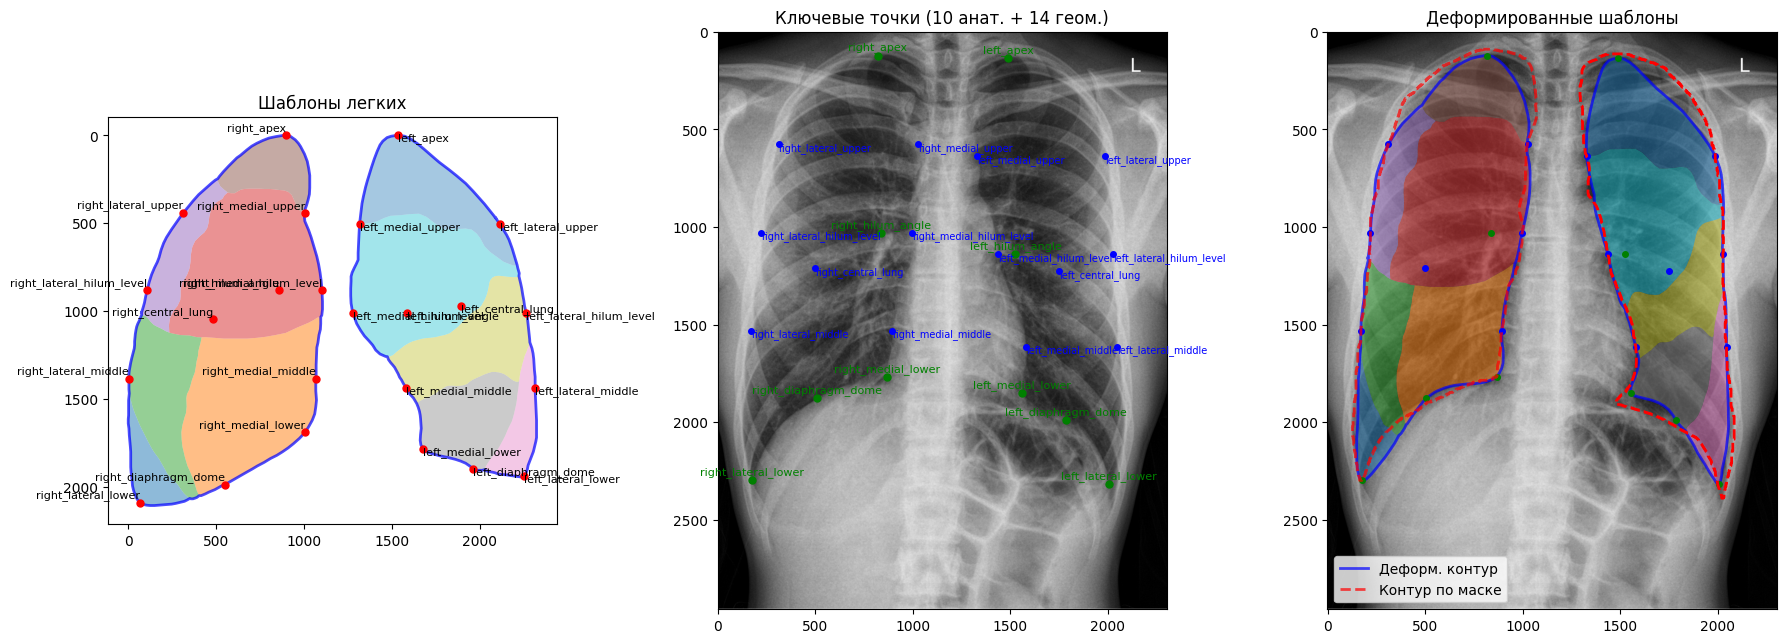

In [119]:
results = process_patient_pipeline(
    patient_id="17123",
    base_path="./part1/data/X-chest-dataset/x-chest/",
    img_path="./part1/data/X-chest-dataset/x-chest/img_PA_fullsize/img_17123.png",
    mod="PA",
    show_visualization=True,
)

### Тест на боковой проекции


Загрузка ключевых точек из ./part1/data/X-chest-dataset/x-chest/key_points_LL_fullsize\key_points_17123_L.mrk.json
Информация об изображении:
  Размер: 2098 x 2932 (ширина x высота)
  Spacing: (0.139, 0.139)

Ключевые точки пациента:
  apex: LPS (188.4, 9.1) → пиксели (1355.6, 65.5)
  hilum_center: LPS (153.3, 115.1) → пиксели (1102.7, 828.3)
  anterior_lower: LPS (34.0, 261.1) → пиксели (244.5, 1878.3)
  posterior_lower: LPS (191.2, 341.5) → пиксели (1375.3, 2456.9)
  left_diaphragm_dome: LPS (110.1, 248.0) → пиксели (791.8, 1784.2)
  right_diaphragm_dome: LPS (110.1, 248.0) → пиксели (791.8, 1784.2)

Загрузка маски из ./part1/data/X-chest-dataset/x-chest/masks_LL_fullsize\seg_17123.png

=== Обработка боковой проекции (LL) ===
  ✓ Найден контур легкого: 'left_lung_lateral_contour'
  ✓ Сегмент: LL10
  ✓ Сегмент: LL9
  ✓ Сегмент: LL7+8
  ✓ Сегмент: LL6
  ✓ Сегмент: LL5
  ✓ Сегмент: LL4
  ✓ Сегмент: LL3
  ✓ Сегмент: LL1+2
  ✓ Ключевая точка: left_diaphragm_dome (742.5, 2146.0)
  ✓ Ключе

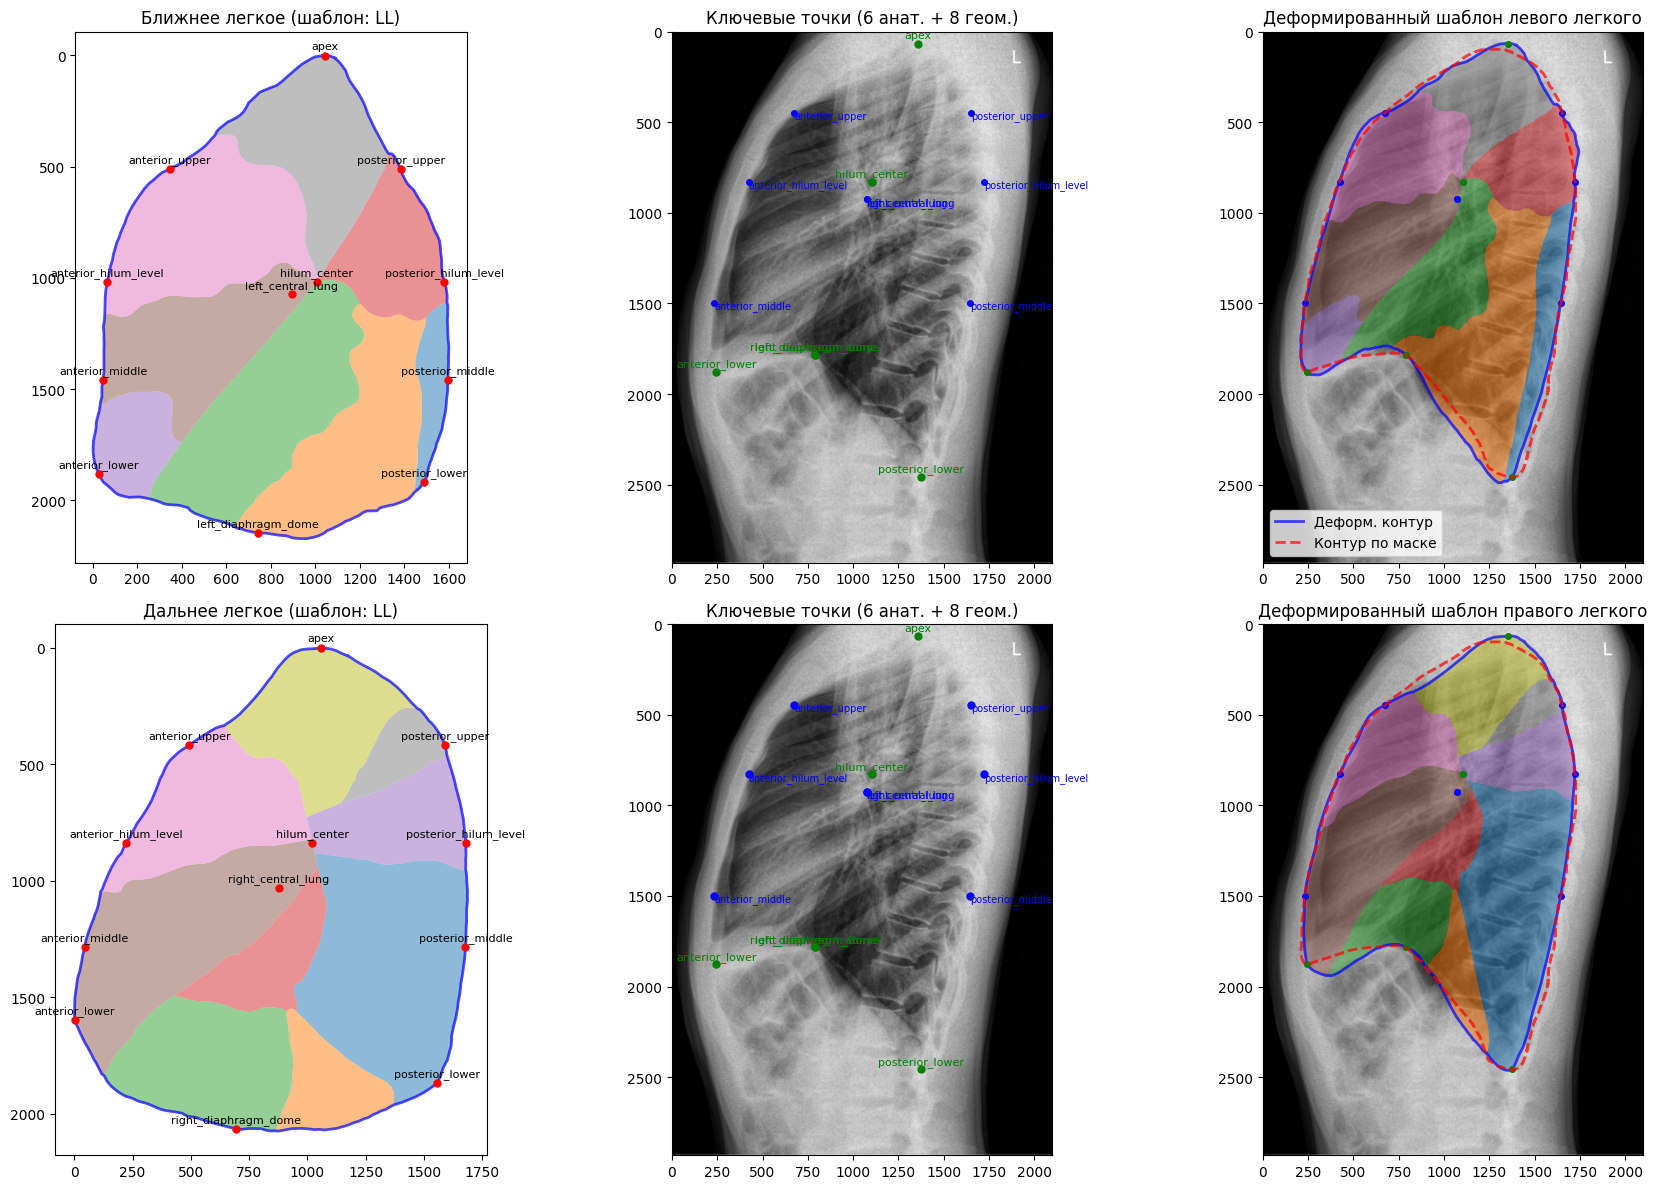

In [121]:
results1 = process_patient_pipeline(
    patient_id="17123",
    base_path="./part1/data/X-chest-dataset/x-chest/",
    img_path="./part1/data/X-chest-dataset/x-chest/img_LL_fullsize/img_17123.png",
    mod="LL",
    show_visualization=True,
)

In [ ]:
# Поправить преобразование координат для уменьшенных масок с учетом падинга
# Поправить вывод геометрических точек на боковой проекции

## Детектор ключевых точек